In [111]:
# Installing necessary libraries.
!pip install wordcloud matplotlib seaborn pandas numpy

In [112]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


# Web Scraping and Data Analysis - LAB01

This notebook demonstrates how to scrape book data from a website using Scrapy, preprocess the data, and generate insightful visualizations and a statistical summary.

## Task 1 - Data Scraping

We define a Scrapy spider class (`DetailedBooksSpider`) that will crawl the `books.toscrape.com` website. Here, we have extracted data from 5 pages.


In [113]:
import scrapy

class DetailedBooksSpider(scrapy.Spider):
    name = "books_detailed"
    start_urls = ["https://books.toscrape.com/catalogue/page-1.html"]

    page_count = 1
    max_pages = 5  # Scrapes 5 catalog pages

    def parse(self, response):
        # 1. Extract links to individual book pages on the current listing page
        book_links = response.css("article.product_pod h3 a::attr(href)").getall()
        for link in book_links:
            yield response.follow(link, callback=self.parse_book)

        # 2. Pagination handling
        next_page = response.css("li.next a::attr(href)").get()
        if next_page is not None and self.page_count < self.max_pages:
            self.page_count += 1
            yield response.follow(next_page, callback=self.parse)

    def parse_book(self, response):
        # Helper function to extract specific table values
        def get_table_val(label):
            return response.xpath(
                f"//th[text()='{label}']/following-sibling::td/text()"
            ).get()

        # Get the raw extracted records with all attributes
        yield {
            "title": response.css("div.product_main h1::text").get(),
            "category": response.css("ul.breadcrumb li:nth-child(3) a::text").get(),
            "price": get_table_val("Price (incl. tax)"),
            "rating": response.css("p.star-rating::attr(class)").get(),
            "availability": get_table_val("Availability"),
            "product_description": response.xpath(
                "//div[@id='product_description']/following-sibling::p/text()"
            ).get(),
            "upc": get_table_val("UPC"),
            "number_of_reviews": get_table_val("Number of reviews"),
            "url": response.url,
        }

## Run the Scrapy Spider

We'll use `CrawlerProcess` to run our spider. The scraped data will be saved into a JSON file named `raw_books.json`.

In [114]:
import json
import os
from scrapy.crawler import CrawlerProcess
from twisted.internet import reactor

# This helps prevent "RuntimeError: This event loop is already running"
if reactor.running:
    reactor.stop()

# Instantiate a CrawlerProcess
process = CrawlerProcess(settings={
    'FEEDS': {
        'raw_books.json': {
            'format': 'json',
            'encoding': 'utf8',
            'store_empty': False,
            'overwrite': True
        }
    },
    'LOG_ENABLED': False,
})

# Start the crawl
process.crawl(DetailedBooksSpider)
process.start()

print("Scraping complete. Data saved to raw_books.json.")

# Display the first few lines of the JSON file to confirm content
try:
    if os.path.exists('raw_books.json'):
        with open('raw_books.json', 'r') as f:
            first_lines = [next(f) for x in range(5)]
            print("\nFirst 5 lines of raw_books.json:")
            for line in first_lines:
                print(line.strip())
    else:
        print("raw_books.json not found, scraping might have failed.")
except Exception as e:
    print(f"Error reading raw_books.json: {e}")

INFO:scrapy.utils.log:Scrapy 2.17.0 started (bot: scrapybot)
INFO:scrapy.utils.log:Versions:
{'lxml': '6.1.1',
 'libxml2': '2.14.6',
 'cssselect': '1.5.0',
 'parsel': '1.11.0',
 'w3lib': '2.4.1',
 'Twisted': '26.4.0',
 'Python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]',
 'pyOpenSSL': '26.3.0 (OpenSSL 4.0.1 9 Jun 2026)',
 'cryptography': '49.0.0',
 'Platform': 'Linux-6.6.122+-x86_64-with-glibc2.35'}
DEBUG:scrapy.crawler:Using CrawlerProcess
INFO:scrapy.addons:Enabled addons:
[]


Scraping complete. Data saved to raw_books.json.

First 5 lines of raw_books.json:
[
{"title": "The Black Maria", "category": "Poetry", "price": "£52.15", "rating": "star-rating One", "availability": "In stock (19 available)", "product_description": "Praise for Aracelis Girmay:\"[Girmay's] every loss—she calls them estrangements—is a yearning for connection across time and place; her every fragment is a bulwark against ruin.\" — O, The Oprah Magazine \"In Aracelis Girmay we have a poet who collects, polishes, and shares stories with such brilliant invention, tenderness, and intellectual liveliness that it is understandabl Praise for Aracelis Girmay:\"[Girmay's] every loss—she calls them estrangements—is a yearning for connection across time and place; her every fragment is a bulwark against ruin.\" — O, The Oprah Magazine \"In Aracelis Girmay we have a poet who collects, polishes, and shares stories with such brilliant invention, tenderness, and intellectual liveliness that it is under

## Task 2 - Data Preprocessing

Now we have the raw data, we will load it into a Pandas DataFrame for easier manipulation and analysis. Start by checking the total number of records, identify any missing values, and look for duplicate entries based on the 'UPC' attribute.

In [115]:
import pandas as pd
import numpy as np

print("\nDATA ANALYSIS")
raw_df = pd.read_json("raw_books.json")
print(f"Total Scraped Records: {len(raw_df)}")
print("""\nMissing Values per Attribute:""")
print(raw_df.isnull().sum())
print(f"""\nDuplicate UPC Count: {raw_df.duplicated('upc').sum()}""")

Unhandled error in Deferred:
CRITICAL:twisted:Unhandled error in Deferred:
CRITICAL:twisted:Unhandled error in Deferred:
CRITICAL:twisted:Unhandled error in Deferred:
CRITICAL:twisted:Unhandled error in Deferred:
CRITICAL:twisted:Unhandled error in Deferred:
CRITICAL:twisted:Unhandled error in Deferred:
CRITICAL:twisted:Unhandled error in Deferred:
CRITICAL:twisted:Unhandled error in Deferred:
CRITICAL:twisted:Unhandled error in Deferred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/twisted/internet/defer.py", line 1834, in _inlineCallbacks
    result = context.run(
  File "/usr/local/lib/python3.12/dist-packages/twisted/python/failure.py", line 467, in throwExceptionIntoGenerator
    return g.throw(self.value.with_traceback(self.tb))
  File "/usr/local/lib/python3.12/dist-packages/scrapy/crawler.py", line 469, in _crawl
    yield d
  File "/usr/local/lib/python3.12/dist-packages/twisted/internet/defer.py", line 1838, in _inlineCallbacks
    resul


DATA ANALYSIS
Total Scraped Records: 100

Missing Values per Attribute:
title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
upc                    0
number_of_reviews      0
url                    0
dtype: int64

Duplicate UPC Count: 0


We'll remove any duplicate book entries based on their 'UPC' to ensure each book is uniquely represented.

In [116]:
df = raw_df.copy()
df = df.drop_duplicates(subset=["upc"])
print(f"Records after deduplication: {len(df)}")

Records after deduplication: 100


### Clean Text Data

In [117]:
df["title"] = df["title"].astype(str).str.strip()
df["category"] = df["category"].astype(str).str.strip()
df["product_description"] = (
    df["product_description"]
    .fillna("No description available.")
    .astype(str)
    .str.strip()
)
print("Text columns cleaned.")

Text columns cleaned.


### Extract Numeric Values


In [118]:
import re

# Price (£51.77 -> 51.77)
df["price_numeric"] = df["price"].apply(
    lambda x: float(re.sub(r"[^\d.]", "", str(x))) if pd.notnull(x) else np.nan
)

# Rating string to integer ('star-rating Three' -> 3)
rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
df["rating_numeric"] = df["rating"].apply(
    lambda x: rating_map.get(str(x).replace("star-rating ", "").strip(), np.nan)
)

# Stock count extraction
df["stock_count"] = df["availability"].apply(
    lambda x: int(re.search(r"\d+", str(x)).group()) if re.search(r"\d+", str(x)) else 0
)

# Reviews count extraction
df["number_of_reviews"] = df["number_of_reviews"].apply(
    lambda x: int(re.search(r"\d+", str(x)).group()) if re.search(r"\d+", str(x)) else 0
)
print("Numeric values extracted and converted.")

Numeric values extracted and converted.


### Create New Features




In [119]:
# Feature 1: Description Word Count
df["description_word_count"] = df["product_description"].apply(
    lambda x: len(re.findall(r"\w+", x))
)

# Feature 2: Price Band (Low, Medium, High)
df["price_band"] = pd.qcut(df["price_numeric"], q=3, labels=["Low", "Medium", "High"])

# Feature 3: Affordability Score (0 to 1 scaling, 1 = most affordable)
min_p, max_p = df["price_numeric"].min(), df["price_numeric"].max()
df["affordability_score"] = round(1 - (df["price_numeric"] - min_p) / (max_p - min_p), 2)

# Feature 4: Value Score (Rating / Price)
df["value_score"] = round(df["rating_numeric"] / df["price_numeric"], 4)

# Export Cleaned Dataset
df.to_csv("cleaned_books.csv", index=False)
print("Cleaned dataset successfully saved to 'cleaned_books.csv'.")
print("New features created: description_word_count, price_band, affordability_score, value_score.")

Cleaned dataset successfully saved to 'cleaned_books.csv'.
New features created: description_word_count, price_band, affordability_score, value_score.


## Task 3 - Visualization and Analysis
 We'll create several plots and a word cloud to summarize key aspects of the book data.


In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

# Initial summary statistics
print("SUMMARY STATISTICS")
display(df[['price_numeric', 'rating_numeric', 'stock_count']].describe())

print("\nCATEGORY DISTRIBUTION (Top 10)")
display(df['category'].value_counts().head(10))

print("\nMISSING & UNUSUAL VALUES")
print("Missing values per column:\n", df.isnull().sum())
print("\nUnusual Values Check:")
print(f"Prices <= 0: {(df['price_numeric'] <= 0).sum()}")
print(f"Ratings outside [1, 5]: {((df['rating_numeric'] < 1) | (df['rating_numeric'] > 5)).sum()}")
print(f"Negative Stock: {(df['stock_count'] < 0).sum()}")

SUMMARY STATISTICS


,price_numeric,rating_numeric,stock_count
count,100.000000,100.000000,100.000000
mean,34.560700,2.930000,17.180000
std,14.638531,1.423149,1.479694
min,10.160000,1.000000,16.000000
25%,19.897500,2.000000,16.000000
50%,34.775000,3.000000,16.000000
75%,47.967500,4.000000,19.000000
max,58.110000,5.000000,22.000000



CATEGORY DISTRIBUTION (Top 10)


,count
category,
Sequential Art,14
Nonfiction,12
Default,9
Poetry,7
Fiction,5
Food and Drink,5
Add a comment,5
History,4
Young Adult,4



MISSING & UNUSUAL VALUES
Missing values per column:
 title                     0
category                  0
price                     0
rating                    0
availability              0
product_description       0
upc                       0
number_of_reviews         0
url                       0
price_numeric             0
rating_numeric            0
stock_count               0
description_word_count    0
price_band                0
affordability_score       0
value_score               0
dtype: int64

Unusual Values Check:
Prices <= 0: 0
Ratings outside [1, 5]: 0
Negative Stock: 0


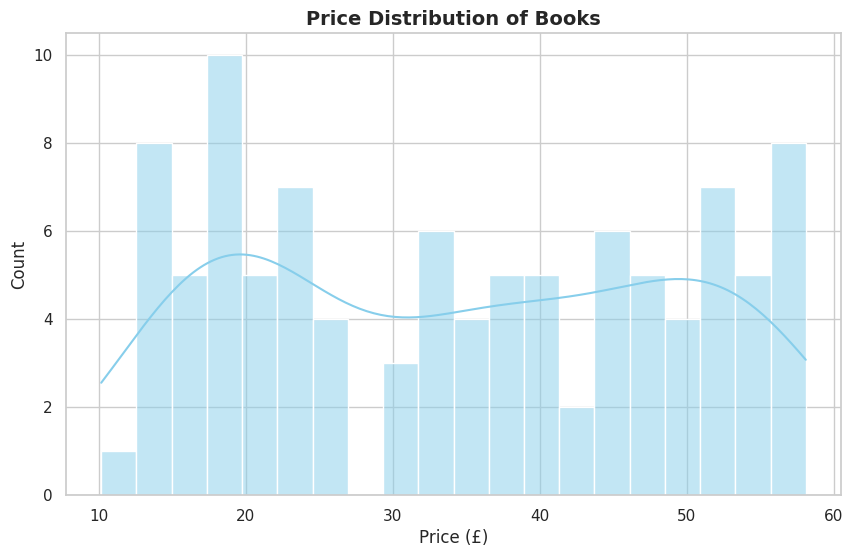

In [121]:
# PLOTS GENERATION
plt.figure(figsize=(10, 6))
# Plot 1: Price Distribution
sns.histplot(df['price_numeric'], kde=True, color='skyblue', bins=20)
plt.title('Price Distribution of Books', fontsize=14, fontweight='bold')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.show()


### Star Rating Distribution

This bar plot illustrates how star ratings are distributed among the books, showing the frequency of each rating (1 to 5 stars).

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/tmp/ipykernel_3978/4211571772.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating_numeric', data=df, palette='Blues_d')
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


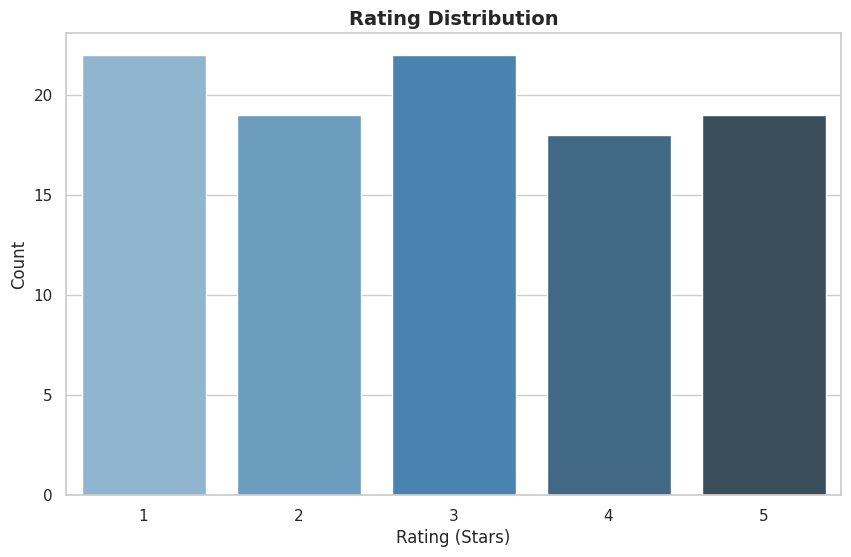

In [122]:
# Plot 2: Rating Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='rating_numeric', data=df, palette='Blues_d')
plt.title('Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating (Stars)')
plt.ylabel('Count')
plt.show()

### Top Categories by Average Price

This horizontal bar chart highlights the book categories with the highest average prices, giving an idea of which genres tend to be more expensive.

/tmp/ipykernel_3978/1095024165.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price_numeric', y='category', data=avg_price_cat, palette='viridis')


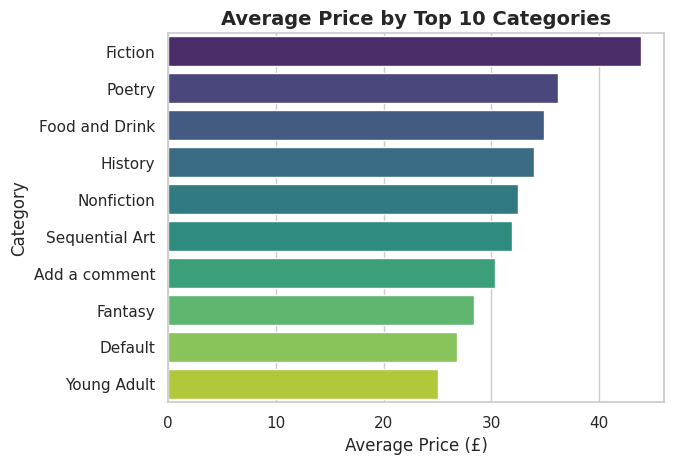

In [123]:
# Plot 3: Average Price by Top Categories
top_cats_list = df['category'].value_counts().head(10).index
avg_price_cat = (
    df[df['category'].isin(top_cats_list)]
    .groupby('category')['price_numeric']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
sns.barplot(x='price_numeric', y='category', data=avg_price_cat, palette='viridis')
plt.title('Average Price by Top 10 Categories', fontsize=14, fontweight='bold')
plt.xlabel('Average Price (£)')
plt.ylabel('Category')
plt.show()

### Price vs. Star Rating

This box plot visualizes the relationship between a book's price and its star rating, helping to see if higher-rated books tend to be more or less expensive.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/tmp/ipykernel_3978/1780253489.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating_numeric', y='price_numeric', data=df, palette='Set2')
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


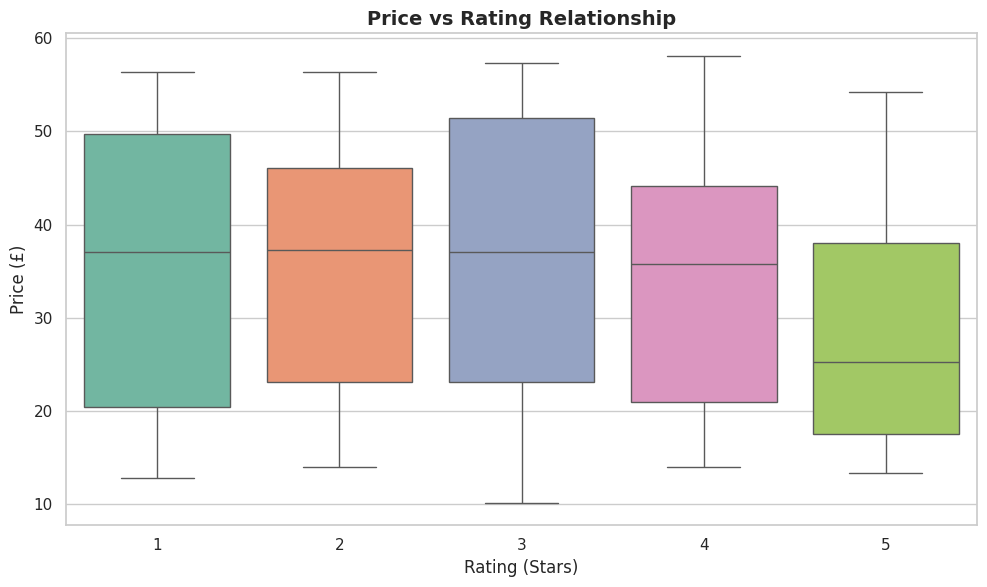

In [124]:
# Plot 4: Relationship - Price vs Rating
plt.figure(figsize=(10, 6))
sns.boxplot(x='rating_numeric', y='price_numeric', data=df, palette='Set2')
plt.title('Price vs Rating Relationship', fontsize=14, fontweight='bold')
plt.xlabel('Rating (Stars)')
plt.ylabel("Price (£)")

plt.tight_layout()
plt.show()

### Book Descriptions Word Cloud

A word cloud visually represents the most frequent words in the product descriptions.

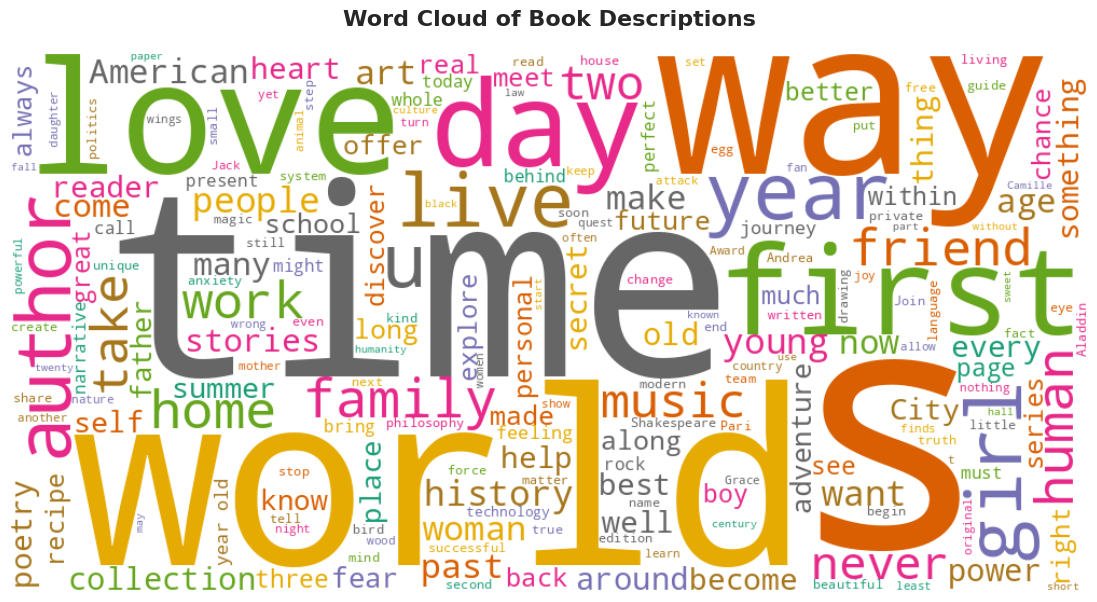

In [125]:
# Combine non-null descriptions into a single text body
description_text = " ".join(df['product_description'].dropna().astype(str))

stopwords = set(STOPWORDS)
stopwords.update(["book", "story", "one", "will", "new", "life", "find"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stopwords,
    colormap='Dark2'
).generate(description_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Book Descriptions', fontsize=16, fontweight='bold', pad=20)
plt.show()

## Task 4 - Insights and Interpretation



In [126]:
print("HIGHLY RATED BOOKS")
high_rated = df[df['rating_numeric'] == 5][['title', 'category', 'price_numeric']].head(5)
display(high_rated)

HIGHLY RATED BOOKS


,title,category,price_numeric
4,Scott Pilgrim's Precious Little Life (Scott Pi...,Sequential Art,52.29
8,Rip it Up and Start Again,Music,35.02
9,Set Me Free,Young Adult,17.46
16,Sapiens: A Brief History of Humankind,History,54.23
24,Sophie's World,Philosophy,15.94


In [127]:
print("CATEGORY PATTERNS")
top_cat_name = df['category'].value_counts().index[0]
print(f"Most Frequent Category: {top_cat_name} ({df['category'].value_counts().iloc[0]} titles)")
highest_priced_cat = avg_price_cat.iloc[0]['category']
highest_priced_val = avg_price_cat.iloc[0]['price_numeric']
print(f"Most Expensive Top Category on Average: {highest_priced_cat} (£{highest_priced_val:.2f})")

CATEGORY PATTERNS
Most Frequent Category: Sequential Art (14 titles)
Most Expensive Top Category on Average: Fiction (£43.87)
